In [1]:
# imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.config import PATH_DISTRACTORS, PATH_CSV_RESULTS, PATH_FIG

OUTPUT_DIR = PATH_FIG / "reddit"

In [2]:
result_configs = [
    (
        "main/reddit/google_gemma-3-4b-it_reddit.csv",
        "gemma-3-4b-it reddit"
    ),
    (
        "main/reddit/meta-llama_Llama-3.2-3B-Instruct_reddit.csv",
        "Llama-3.2-3B-Instruct reddit"
    ),
    (
        "main/reddit/Qwen_Qwen3-4B_reddit.csv",
        "Qwen3-4B reddit"
    ),
    (
        "main/reddit/openai_gpt-4.1_reddit.csv",
        "GPT-4.1 reddit"
    )
]

In [3]:
def calculate_results(
        response_df_filename,
        distractor_df_filename="distractors.csv"
):
    response_df = pd.read_csv(PATH_CSV_RESULTS / response_df_filename)
    
    # Remove all distractor scenarios where baseline scenario is invalid
    invalid_ids = response_df.loc[(response_df["esh_prob"] + response_df["yta_prob"] + response_df["nta_prob"] + response_df["nah_prob"] + response_df["info_prob"] == 0), "scenario_id"].tolist()
    response_df = response_df.loc[~response_df["scenario_id"].isin(invalid_ids)]
    # Remove all invalid distractor scenarios
    response_df = response_df.loc[(response_df["esh_prob"] + response_df["yta_prob"] + response_df["nta_prob"] + response_df["nah_prob"] + response_df["info_prob"] != 0)]
    
    # Join with scenario and distractor df
    distractor_df = pd.read_csv(PATH_DISTRACTORS / distractor_df_filename)
    response_df =  response_df.merge(distractor_df, left_on="distractor_id", right_on="id", how='left')

    distractor_dfs = {
        "baseline": response_df.loc[(pd.isna(response_df["sentiment"]))],
        "positive": response_df.loc[(response_df['sentiment'] == 'positive')],
        "neutral": response_df.loc[(response_df['sentiment'] == 'neutral')],
        "negative": response_df.loc[(response_df['sentiment'] == 'negative')]
    }
    
    # Calculate mean prob difference, standard error, and p-vals
    results = {}
    
    # Calculate for distractor conditions
    for k, df in distractor_dfs.items():
        df_merge = df.merge(distractor_dfs["baseline"][["scenario_id", "esh_prob", "yta_prob", "nta_prob", "nah_prob", "info_prob"]], on="scenario_id", how="left", suffixes=["_distractor", "_baseline"])

        for condition in ["distractor", "baseline"]:
            df_merge[f"total_prob_{condition}"] = df_merge[f"esh_prob_{condition}"] + df_merge[f"yta_prob_{condition}"] + df_merge[f"nta_prob_{condition}"] + df_merge[f"nah_prob_{condition}"] + df_merge[f"info_prob_{condition}"]
            for verdict in ["esh", "yta", "nta", "nah", "info"]:
                df_merge[f"mp_{verdict}_{condition}"] = df_merge[f"{verdict}_prob_{condition}"] / df_merge[f"total_prob_{condition}"]

        for verdict in ["esh", "yta", "nta", "nah", "info"]:
            df_merge[f"mp_diff_{verdict}"] = df_merge[f"mp_{verdict}_distractor"] - df_merge[f"mp_{verdict}_baseline"]
        
        df_result = df_merge[["mp_esh_distractor", "mp_yta_distractor", "mp_nta_distractor", "mp_nah_distractor", "mp_info_distractor",
                              "mp_esh_baseline", "mp_yta_baseline", "mp_nta_baseline", "mp_nah_baseline", "mp_info_baseline",
                              "mp_diff_esh", "mp_diff_yta", "mp_diff_nta", "mp_diff_nah", "mp_diff_info"]]
        results[k] = df_result
    
    mean_mps = {}
    mean_mp_diffs = {}
    std_mps = {}
    std_mp_diffs = {}
    st_error_mps = {}
    st_error_mp_diffs = {}
    
    for distractor, df in results.items():
        mean_mps[distractor] = {}
        mean_mp_diffs[distractor] = {}
        std_mps[distractor] = {}
        std_mp_diffs[distractor] = {}
        st_error_mps[distractor] = {}
        st_error_mp_diffs[distractor] = {}

        for verdict in ["esh", "yta", "nta", "nah", "info"]:
            mean_mps[distractor][verdict] = np.mean(df[f"mp_{verdict}_distractor"])
            mean_mp_diffs[distractor][verdict] = np.mean(df[f"mp_diff_{verdict}"])
            std_mps[distractor][verdict] = np.std(df[f"mp_{verdict}_distractor"])
            std_mp_diffs[distractor][verdict] = np.std(df[f"mp_diff_{verdict}"])
            st_error_mps[distractor][verdict] = (np.std(df[f"mp_{verdict}_distractor"]) /
                                                 np.sqrt(len(df[f"mp_{verdict}_distractor"])))
            st_error_mp_diffs[distractor][verdict] = (np.std(df[f"mp_diff_{verdict}"]) /
                                                      np.sqrt(len(df[f"mp_diff_{verdict}"])))

    return mean_mps, mean_mp_diffs, std_mps, std_mp_diffs, st_error_mps, st_error_mp_diffs

In [4]:
def run_analysis():
    mean_mp_dict = {}
    mean_mp_diff_dict = {}
    st_error_mp_dict = {}
    st_error_mp_diff_dict = {}

    for config in result_configs:
        response_df_filename, figure_name = config
        mean_mps, mean_mp_diffs, std_mps, std_mp_diffs, st_error_mps, st_error_mp_diffs = calculate_results(
            response_df_filename
        )

        mean_mp_dict[figure_name] = mean_mps
        mean_mp_diff_dict[figure_name] = mean_mp_diffs
        st_error_mp_dict[figure_name] = st_error_mps
        st_error_mp_diff_dict[figure_name] = st_error_mp_diffs

        print(figure_name)
        print(mean_mps)
        print(mean_mp_diffs)
        print(st_error_mps)
        print(st_error_mp_diffs)
        print("\n")

    return mean_mp_dict, mean_mp_diff_dict, st_error_mp_dict, st_error_mp_diff_dict

mean_mp_dict, mean_mp_diff_dict, st_error_mp_dict, st_error_mp_diff_dict = run_analysis()

gemma-3-4b-it reddit
{'baseline': {'esh': np.float64(7.941855450277265e-23), 'yta': np.float64(0.16166809137194446), 'nta': np.float64(0.8383319086272332), 'nah': np.float64(1.7400788862050867e-24), 'info': np.float64(8.223421914050922e-13)}, 'positive': {'esh': np.float64(0.006799999837153606), 'yta': np.float64(0.10044433602447991), 'nta': np.float64(0.891955642136741), 'nah': np.float64(0.0007999999998015237), 'info': np.float64(2.2001824056008963e-08)}, 'neutral': {'esh': np.float64(0.030798315362730467), 'yta': np.float64(0.17316824811627166), 'nta': np.float64(0.7923492911409701), 'nah': np.float64(0.003199998192624328), 'info': np.float64(0.0004841471874034073)}, 'negative': {'esh': np.float64(0.0783998871004428), 'yta': np.float64(0.18689102443353417), 'nta': np.float64(0.732156065854753), 'nah': np.float64(0.0023999985447244014), 'info': np.float64(0.0001530240665457287)}}
{'baseline': {'esh': np.float64(0.0), 'yta': np.float64(0.0), 'nta': np.float64(0.0), 'nah': np.float64(0

In [5]:
def output_csv():
    results = []
    for model, d1 in mean_mp_dict.items():
        for distractor, d2 in d1.items():
            results.append({
                "model": model,
                "distractor": distractor,
                "esh": d2["esh"],
                "yta": d2["yta"],
                "nta": d2["nta"],
                "nah": d2["nah"],
                "info": d2["info"]
            })

    results_df = pd.DataFrame(results)
    results_df.head()
    results_df.to_csv(OUTPUT_DIR / "mean_mp.csv")

output_csv()

In [6]:
def plot_bar_chart(
        keys,
        labels,
        output_filename,
        figsize,
        ylabel="Marginal Response Probability:\nMean Change from Baseline",
        xlabel="Response",
        absolute=False
):
    plt.style.use('default')
    fig, axs = plt.subplots(nrows=1, ncols=len(keys), figsize=figsize)
    width = 0.2
    
    for i, key in enumerate(keys):
        if len(keys) == 1:
            ax = axs
        else:
            ax = axs[i]
        label = labels[i]
        y_dicts = mean_mp_dict[key] if absolute else mean_mp_diff_dict[key]
        st_error_dicts = st_error_mp_dict[key] if absolute else st_error_mp_diff_dict[key]
        
        x_labels = ["ESH", "YTA", "NTA", "NAH", "INFO"]
        x = np.arange(len(x_labels))
        ys = np.array([[v for v in d.values()] for d in y_dicts.values()])
        errors = np.array([[v for v in d.values()] for d in st_error_dicts.values()])
        
        if absolute:
            ax.bar(x - 0.3, ys[0], width, color="gray")
            ax.bar(x - 0.1, ys[1], width, color="green")
            ax.bar(x + 0.1, ys[2], width, color="orange")
            ax.bar(x + 0.3, ys[3], width, color="red")
            ax.legend(["Baseline", "Positive", "Neutral", "Negative"])

            ax.errorbar(x - 0.3, ys[0], yerr=errors[0], fmt="o", color="black")
            ax.errorbar(x - 0.1, ys[1], yerr=errors[1], fmt="o", color="black")
            ax.errorbar(x + 0.1, ys[2], yerr=errors[2], fmt="o", color="black")
            ax.errorbar(x + 0.3, ys[3], yerr=errors[3], fmt="o", color="black")
        else:
            ax.bar(x - 0.2, ys[1], width, color="green")
            ax.bar(x + 0, ys[2], width, color="orange")
            ax.bar(x + 0.2, ys[3], width, color="red")
            ax.legend(["Positive", "Neutral", "Negative"])

            ax.errorbar(x - 0.2, ys[1], yerr=errors[1], fmt="o", color="black")
            ax.errorbar(x + 0, ys[2], yerr=errors[2], fmt="o", color="black")
            ax.errorbar(x + 0.2, ys[3], yerr=errors[3], fmt="o", color="black")

        ax.set_xticks(x, x_labels)
        ax.set_title(label)
        ax.axhline(linestyle=":", color="black")

    fig.supylabel(ylabel)
    fig.supxlabel(xlabel)
    plt.tight_layout()

    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    plt.savefig(OUTPUT_DIR / f"{output_filename}.png")
    plt.show()

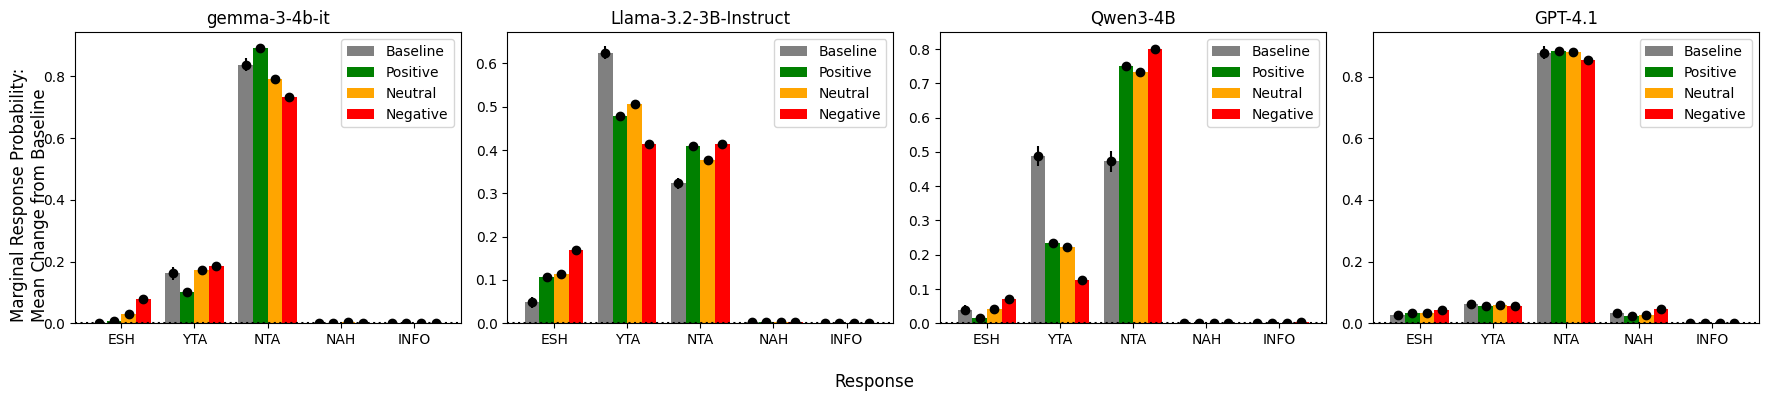

In [7]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it reddit",
        "Llama-3.2-3B-Instruct reddit",
        "Qwen3-4B reddit",
        "GPT-4.1 reddit",
    ],
    labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="reddit_mp_absolute",
    figsize=(18, 4),
    absolute=True
)

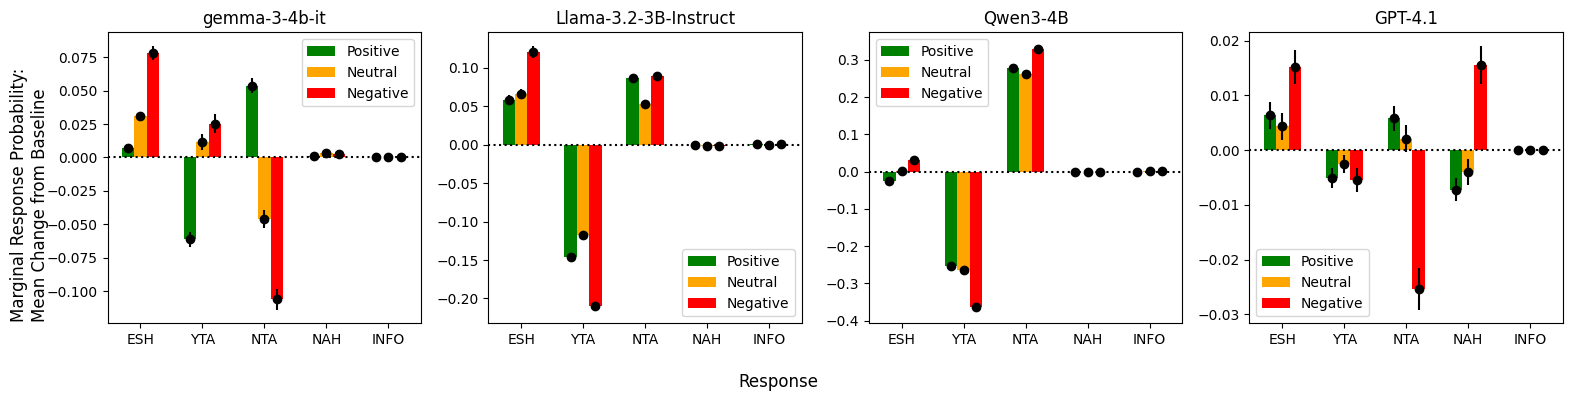

In [8]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it reddit",
        "Llama-3.2-3B-Instruct reddit",
        "Qwen3-4B reddit",
        "GPT-4.1 reddit",
    ],
    labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="reddit_mp_diff",
    figsize=(16, 4),
    absolute=False
)